In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../experiments/results")

fgsm_df = pd.read_csv(
    RESULTS_DIR / "fgsm_results.csv"
)

fgsm_df

,Epsilon,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,FNR,Attack Success Rate,TN,FP,FN,TP
0,0.001,0.969147,0.898405,0.921533,0.909822,0.996086,0.982203,0.021177,0.078467,0.022312,307604,6655,5011,58850
1,0.005,0.931178,0.786166,0.813877,0.799781,0.980925,0.913465,0.044985,0.186123,0.136528,300122,14137,11886,51975
2,0.010,0.894608,0.680364,0.709118,0.694443,0.953351,0.829619,0.067699,0.290882,0.247670,292984,21275,18576,45285
3,0.050,0.732558,0.312544,0.486447,0.380570,0.615033,0.376842,0.217429,0.513553,0.483910,245930,68329,32796,31065
4,0.100,0.514041,0.163192,0.454816,0.240199,0.427701,0.235039,0.473924,0.545184,0.517469,165324,148935,34816,29045


In [2]:
clean = {
    "Accuracy": 0.983680,
    "Precision": 0.960077,
    "Recall": 0.942563,
    "F1": 0.951239,
    "ROC-AUC": 0.998706,
    "PR-AUC": 0.994001,
    "FPR": 0.007965,
    "FNR": 0.057437
}

In [3]:
fgsm_df["Recall Degradation"] = (
    clean["Recall"] -
    fgsm_df["Recall"]
)

fgsm_df["F1 Degradation"] = (
    clean["F1"] -
    fgsm_df["F1"]
)

fgsm_df["Accuracy Degradation"] = (
    clean["Accuracy"] -
    fgsm_df["Accuracy"]
)

fgsm_df["ROC-AUC Degradation"] = (
    clean["ROC-AUC"] -
    fgsm_df["ROC-AUC"]
)

fgsm_df["PR-AUC Degradation"] = (
    clean["PR-AUC"] -
    fgsm_df["PR-AUC"]
)

In [4]:
fgsm_df["FNR Increase"] = (
    fgsm_df["FNR"] -
    clean["FNR"]
)

fgsm_df["FPR Increase"] = (
    fgsm_df["FPR"] -
    clean["FPR"]
)

In [5]:
fgsm_df[
    [
        "Epsilon",
        "Recall Degradation",
        "F1 Degradation",
        "Accuracy Degradation",
        "ROC-AUC Degradation",
        "PR-AUC Degradation",
        "FNR Increase",
        "FPR Increase",
        "Attack Success Rate"
    ]
]

,Epsilon,Recall Degradation,F1 Degradation,Accuracy Degradation,ROC-AUC Degradation,PR-AUC Degradation,FNR Increase,FPR Increase,Attack Success Rate
0,0.001,0.021030,0.041417,0.014533,0.002620,0.011798,0.021030,0.013212,0.022312
1,0.005,0.128686,0.151458,0.052502,0.017781,0.080536,0.128686,0.037020,0.136528
2,0.010,0.233445,0.256796,0.089072,0.045355,0.164382,0.233445,0.059734,0.247670
3,0.050,0.456116,0.570669,0.251122,0.383673,0.617159,0.456116,0.209464,0.483910
4,0.100,0.487747,0.711040,0.469639,0.571005,0.758962,0.487747,0.465959,0.517469


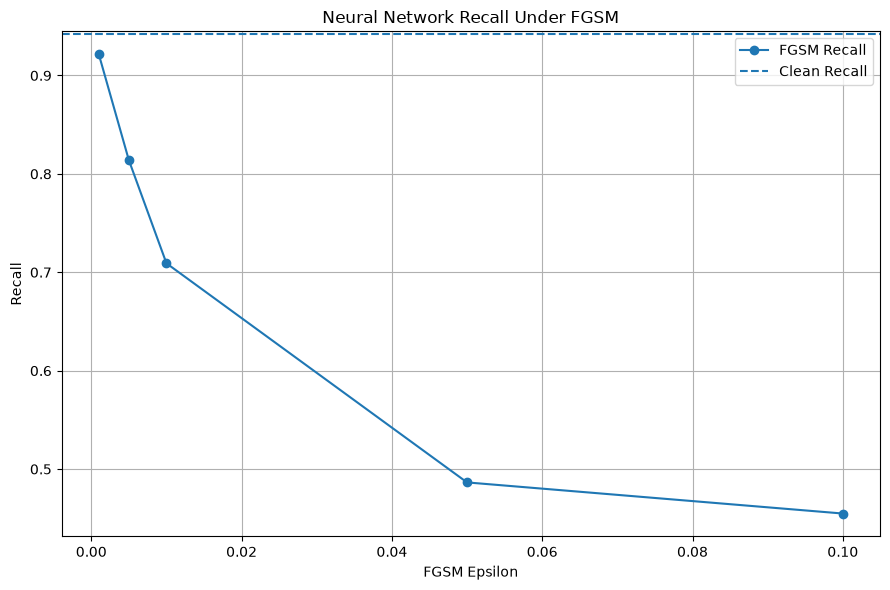

In [6]:
plt.figure(figsize=(9, 6))

plt.plot(
    fgsm_df["Epsilon"],
    fgsm_df["Recall"],
    marker="o",
    label="FGSM Recall"
)

plt.axhline(
    clean["Recall"],
    linestyle="--",
    label="Clean Recall"
)

plt.xlabel("FGSM Epsilon")
plt.ylabel("Recall")
plt.title("Neural Network Recall Under FGSM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

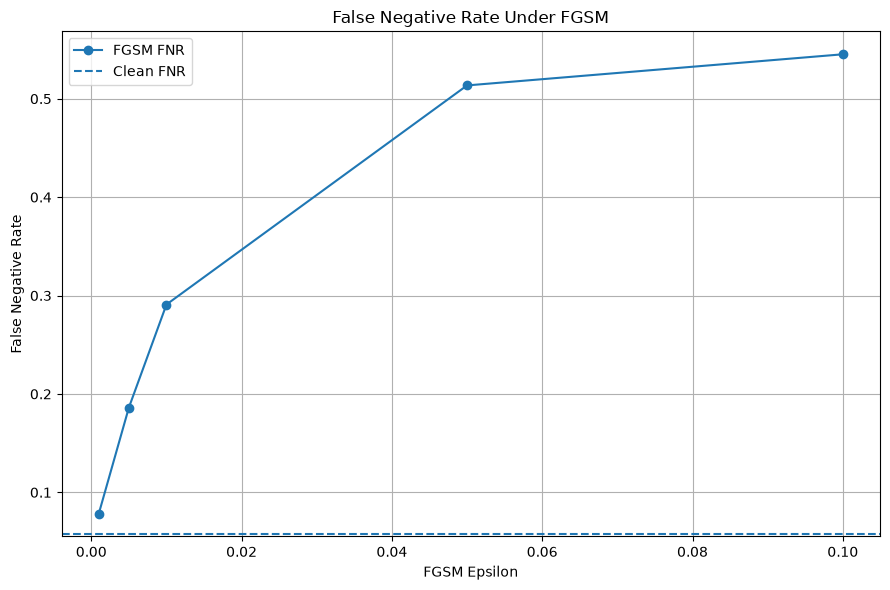

In [7]:
plt.figure(figsize=(9, 6))

plt.plot(
    fgsm_df["Epsilon"],
    fgsm_df["FNR"],
    marker="o",
    label="FGSM FNR"
)

plt.axhline(
    clean["FNR"],
    linestyle="--",
    label="Clean FNR"
)

plt.xlabel("FGSM Epsilon")
plt.ylabel("False Negative Rate")
plt.title("False Negative Rate Under FGSM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

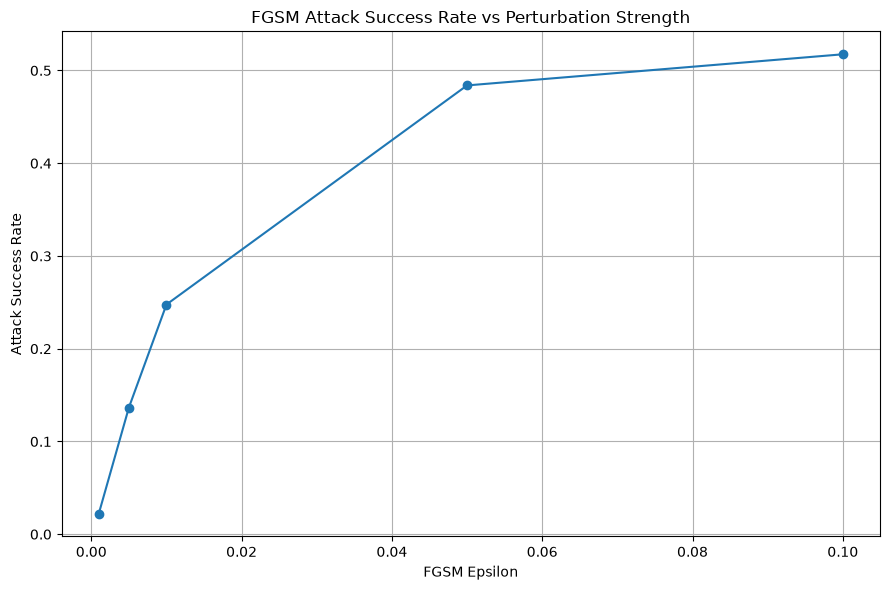

In [8]:
plt.figure(figsize=(9, 6))

plt.plot(
    fgsm_df["Epsilon"],
    fgsm_df["Attack Success Rate"],
    marker="o"
)

plt.xlabel("FGSM Epsilon")
plt.ylabel("Attack Success Rate")
plt.title("FGSM Attack Success Rate vs Perturbation Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

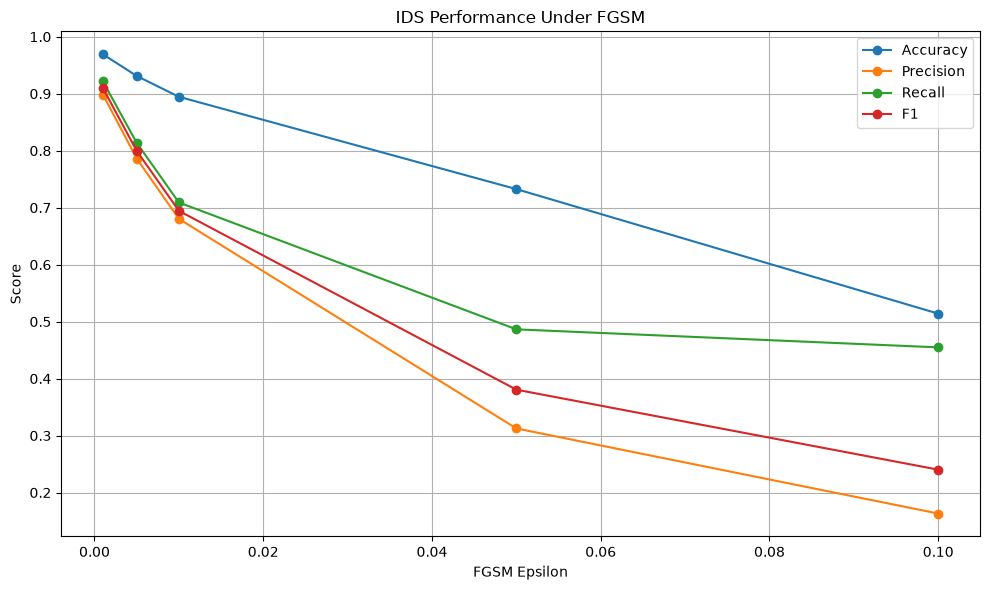

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    fgsm_df["Epsilon"],
    fgsm_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    fgsm_df["Epsilon"],
    fgsm_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    fgsm_df["Epsilon"],
    fgsm_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    fgsm_df["Epsilon"],
    fgsm_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("FGSM Epsilon")
plt.ylabel("Score")
plt.title("IDS Performance Under FGSM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
fgsm_df["Relative Recall Degradation (%)"] = (
    (
        clean["Recall"] -
        fgsm_df["Recall"]
    )
    /
    clean["Recall"]
) * 100

In [11]:
fgsm_df[
    [
        "Epsilon",
        "Recall",
        "Recall Degradation",
        "Relative Recall Degradation (%)"
    ]
]

,Epsilon,Recall,Recall Degradation,Relative Recall Degradation (%)
0,0.001,0.921533,0.021030,2.231182
1,0.005,0.813877,0.128686,13.652773
2,0.010,0.709118,0.233445,24.767019
3,0.050,0.486447,0.456116,48.391022
4,0.100,0.454816,0.487747,51.746893


In [12]:
analysis_columns = [
    "Epsilon",
    "Accuracy",
    "Recall",
    "F1",
    "FNR",
    "FPR",
    "Attack Success Rate",
    "Recall Degradation",
    "F1 Degradation",
    "FNR Increase",
    "FPR Increase"
]

fgsm_analysis = fgsm_df[
    analysis_columns
]

fgsm_analysis

,Epsilon,Accuracy,Recall,F1,FNR,FPR,Attack Success Rate,Recall Degradation,F1 Degradation,FNR Increase,FPR Increase
0,0.001,0.969147,0.921533,0.909822,0.078467,0.021177,0.022312,0.021030,0.041417,0.021030,0.013212
1,0.005,0.931178,0.813877,0.799781,0.186123,0.044985,0.136528,0.128686,0.151458,0.128686,0.037020
2,0.010,0.894608,0.709118,0.694443,0.290882,0.067699,0.247670,0.233445,0.256796,0.233445,0.059734
3,0.050,0.732558,0.486447,0.380570,0.513553,0.217429,0.483910,0.456116,0.570669,0.456116,0.209464
4,0.100,0.514041,0.454816,0.240199,0.545184,0.473924,0.517469,0.487747,0.711040,0.487747,0.465959


In [13]:
fgsm_analysis.to_csv(
    RESULTS_DIR / "fgsm_vulnerability_analysis.csv",
    index=False
)

print("FGSM vulnerability analysis saved.")

FGSM vulnerability analysis saved.


## FGSM Vulnerability Findings

The neural-network IDS demonstrated increasing vulnerability
as the FGSM perturbation magnitude increased.

The measured attack success rate increased from 2.23% at
epsilon = 0.001 to 51.75% at epsilon = 0.1.

Recall decreased from the clean baseline of approximately
94.26% to approximately 45.48% at epsilon = 0.1.

The false negative rate also increased substantially,
indicating that adversarial perturbations caused the IDS
to miss a larger proportion of malicious samples.

These results demonstrate that high clean-data performance
does not necessarily imply robustness against adversarial
perturbations.